In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import sys
import time
from IPython.display import display
import re
import json
import sqlite3

In [2]:
# Load the latest version
file_path = "./data/dataset.csv"

df = pd.read_csv(file_path)
df = df.drop(columns=["Value"], errors="ignore")

print("First 5 records:\n", df.head())

First 5 records:
              Name     Nationality  Age Overall rating  \
0     J. Manzambi     Switzerland   19             77   
1       S. Baidoo         Austria   21             76   
2     14J. Putupu  American Samoa   37             39   
3  A. Al Khaibari    Saudi Arabia   28             70   
4       C. Varela        Portugal   16             68   

            Team & Contract      Height       Weight   foot Best position  \
0    SC Freiburg2024 ~ 2030  183cm 6'0"  75kg 165lbs  Right           CAM   
1        RC Lens2025 ~ 2030  190cm 6'3"  82kg 181lbs  Right            CB   
2        American SamoaFree  170cm 5'7"  73kg 161lbs  Right            CB   
3       Al Nassr2019 ~ 2029  175cm 5'9"  75kg 165lbs  Right           CDM   
4  Dinamo Zagreb2025 ~ 2028  169cm 5'7"  60kg 132lbs  Right            RM   

   Total attacking  Total skill  Total movement  Total power  Total mentality  \
0              332          339             392          373              344   
1             

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Name             12000 non-null  str  
 1   Nationality      12000 non-null  str  
 2   Age              12000 non-null  int64
 3   Overall rating   12000 non-null  str  
 4   Team & Contract  12000 non-null  str  
 5   Height           12000 non-null  str  
 6   Weight           12000 non-null  str  
 7   foot             12000 non-null  str  
 8   Best position    12000 non-null  str  
 9   Total attacking  12000 non-null  int64
 10  Total skill      12000 non-null  int64
 11  Total movement   12000 non-null  int64
 12  Total power      12000 non-null  int64
 13  Total mentality  12000 non-null  int64
 14  Total defending  12000 non-null  int64
 15  Body type        12000 non-null  str  
dtypes: int64(7), str(9)
memory usage: 1.5 MB


In [4]:
rows_before_gk_filter = len(df)

df = df.loc[
    df["Best position"].astype("string").str.strip().str.upper().ne("GK")
].copy()

print(f"Removed {rows_before_gk_filter - len(df):,} GK players.")
print(f"Remaining players: {len(df):,}")

Removed 1,251 GK players.
Remaining players: 10,749


In [5]:
# Kiểm tra và loại bỏ các hàng dữ liệu bị lặp
duplicates = df.duplicated().sum()
print(f"Số lượng hàng bị lặp: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates(keep='first')
    print(f"Số lượng hàng còn lại: {len(df):,}")
else:
    print("Không có hàng nào bị lặp.")

Số lượng hàng bị lặp: 575
Số lượng hàng còn lại: 10,174


In [6]:
def normalize_team(series):
    return (
        series.astype("string")
        .str.replace(r"(?:\d{4}.*|[A-Z][a-z]{2} \d{1,2}, \d{4}.*|Free)$", "", regex=True)
        .str.strip()
    )


def normalize_measure(series, unit):
    values = series.astype("string").str.extract(
        rf"(\d+(?:\.\d+)?)\s*{unit}", expand=False
    )
    return pd.to_numeric(values, errors="coerce").astype("Float64")


def normalize_value(series):
    values = series.astype("string").str.extract(
        r"€?\s*(\d+(?:\.\d+)?)\s*([KMB])?", expand=False
    )
    number = pd.to_numeric(values[0], errors="coerce")
    multiplier = values[1].map({"K": 0.001, "M": 1, "B": 1000}).fillna(1)
    return (number * multiplier).astype("Float64")


def normalize_body_type(series):
    return series.astype("string").str.replace(
        r"\s*\([^)]*\)", "", regex=True
    ).str.strip()


# Keep only the requested unit or text portion in each field.
df["Team & Contract"] = normalize_team(df["Team & Contract"])
df["Height"] = normalize_measure(df["Height"], "cm")
df["Weight"] = normalize_measure(df["Weight"], "kg")
df["Body type"] = normalize_body_type(df["Body type"])


output_path = "./data/dataset_cleaned.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(
    f"Saved {len(df):,} rows to {output_path}"
)
df[["Team & Contract", "Height", "Weight", "Body type"]].head()

Saved 10,174 rows to ./data/dataset_cleaned.csv


,Team & Contract,Height,Weight,Body type
0,SC Freiburg,183.0,75.0,Normal
1,RC Lens,190.0,82.0,Normal
2,American Samoa,170.0,73.0,Stocky
3,Al Nassr,175.0,75.0,Lean
4,Dinamo Zagreb,169.0,60.0,Lean


In [7]:
# Add a unique row identifier and classify every column.
if "ID" in df.columns:
    df = df.drop(columns="ID")
df.insert(0, "ID", range(1, len(df) + 1))

numeric_columns = [
    "Age",
    "Overall rating",
    "Height",
    "Weight",
    "Total attacking",
    "Total skill",
    "Total movement",
    "Total power",
    "Total mentality",
    "Total defending",
]
categorical_columns = [
    "Name",
    "Nationality",
    "Team & Contract",
    "foot",
    "Best position",
    "Body type",
]

column_types = pd.DataFrame({"Column": df.columns})
column_types["Type"] = column_types["Column"].map(
    lambda column: "Key" if column == "ID"
    else "Numeric" if column in numeric_columns
    else "Categorical" if column in categorical_columns
    else "Unknown"
)

if column_types["Type"].eq("Unknown").any():
    raise ValueError(
        f"Unclassified columns: {column_types.loc[column_types['Type'].eq('Unknown'), 'Column'].tolist()}"
    )

output_path = "./data/dataset_cleaned.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Added unique ID for {len(df):,} rows")
print(f"Saved classified dataset to {output_path}")
column_types

Added unique ID for 10,174 rows
Saved classified dataset to ./data/dataset_cleaned.csv


,Column,Type
0,ID,Key
1,Name,Categorical
2,Nationality,Categorical
3,Age,Numeric
4,Overall rating,Numeric
5,Team & Contract,Categorical
6,Height,Numeric
7,Weight,Numeric
8,foot,Categorical
9,Best position,Categorical


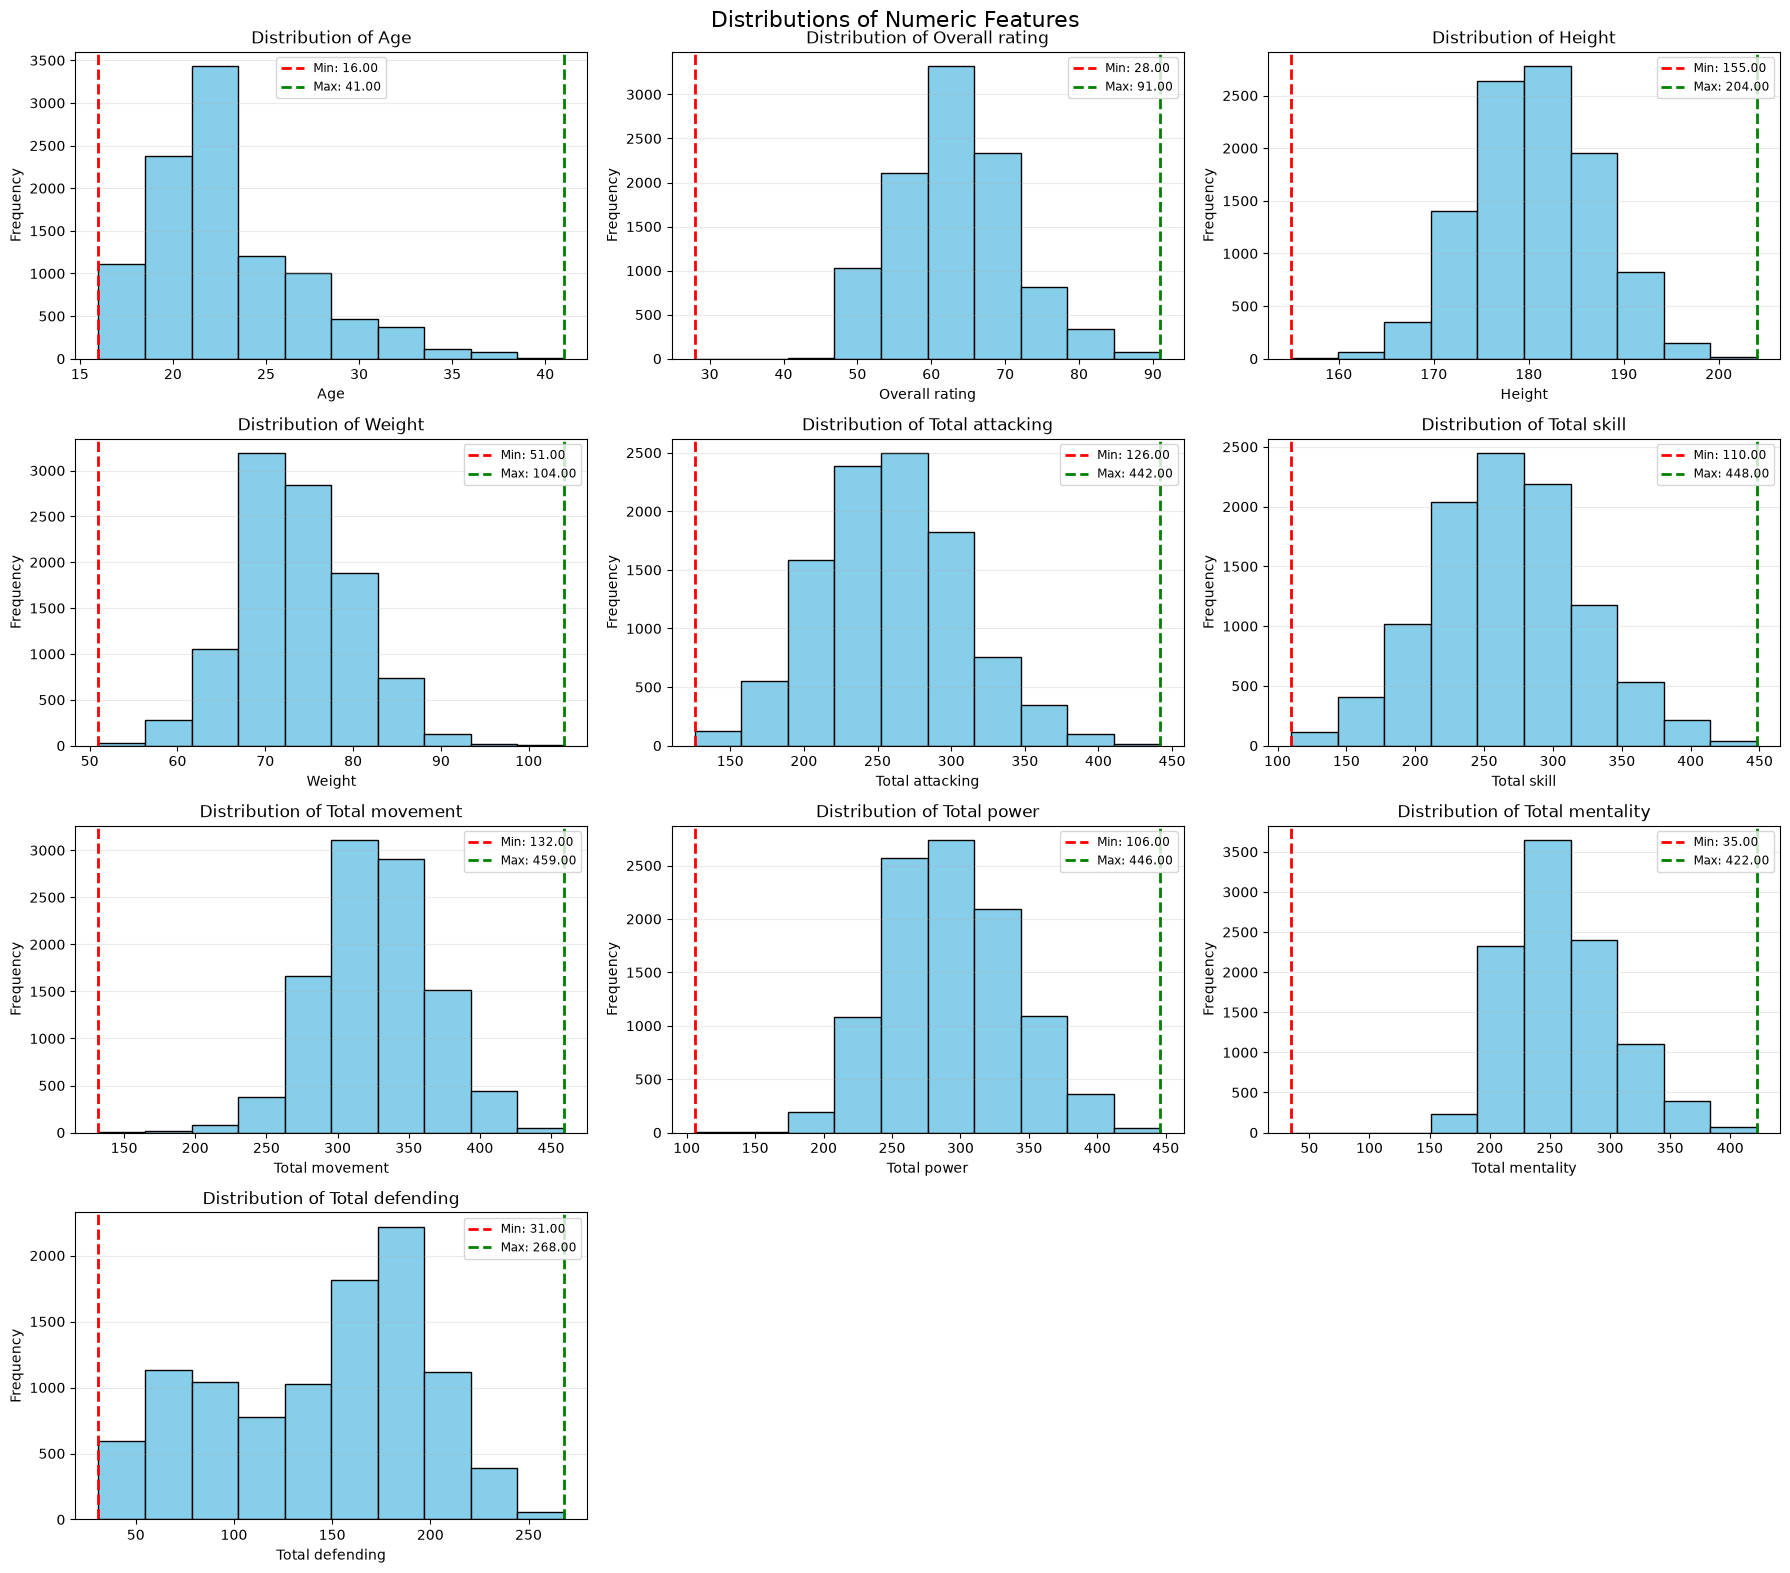

In [8]:
# Plot numeric distributions, using log transformation for skewed features.
numeric_data = df[numeric_columns].apply(pd.to_numeric, errors="coerce")
log_transformed_columns = set()
numeric_data[list(log_transformed_columns)] = np.log1p(
    numeric_data[list(log_transformed_columns)]
)

number_of_columns = 3
number_of_rows = int(np.ceil(len(numeric_columns) / number_of_columns))
fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(18, 4 * number_of_rows),
)
axes = np.asarray(axes).reshape(-1)

for axis, column in zip(axes, numeric_columns):
    col_data = numeric_data[column].dropna()
    
    # Vẽ biểu đồ Histogram
    axis.hist(
        col_data,
        bins=10,
        color="skyblue",
        edgecolor="black",
    )
    
    # Đánh dấu (highlight) Min và Max
    if not col_data.empty:
        min_val = col_data.min()
        max_val = col_data.max()
        axis.axvline(min_val, color="red", linestyle="dashed", linewidth=2, label=f"Min: {min_val:.2f}")
        axis.axvline(max_val, color="green", linestyle="dashed", linewidth=2, label=f"Max: {max_val:.2f}")
        axis.legend(fontsize="small", loc="best")
    
    axis_title = f"Distribution of {column}"
    axis_label = column
    if column in log_transformed_columns:
        axis_title += " (Log Transformed)"
        axis_label += " - log1p"
    axis.set_title(axis_title)
    axis.set_xlabel(axis_label)
    axis.set_ylabel("Frequency")
    axis.grid(axis="y", alpha=0.25)

for axis in axes[len(numeric_columns):]:
    axis.set_visible(False)

fig.suptitle("Distributions of Numeric Features", fontsize=16)
fig.tight_layout()
plt.show()


In [9]:
# Create a separate CSV with prefixed categorical values and tokenized numeric values.
categorical_prefixes = {
    "Nationality": "Na",
    "Team & Contract": "Tc",
    "foot": "F",
    "Best position": "Bp",
    "Body type": "Bt",
}
numeric_prefixes = {
    "Age": "a",
    "Overall rating": "o",
    "Height": "h",
    "Weight": "w",
    "Total attacking": "ta",
    "Total skill": "ts",
    "Total movement": "tm",
    "Total power": "tp",
    "Total mentality": "tme",
    "Total defending": "td",
}

tokenized_df = df[["ID", *categorical_columns]].copy()

for column, prefix in categorical_prefixes.items():
    tokenized_df[column] = (
        tokenized_df[column]
        .astype("string")
        .map(lambda value: f"{prefix}_{value}" if pd.notna(value) else "NA")
    )

for column, prefix in numeric_prefixes.items():
    values = pd.to_numeric(df[column], errors="coerce")
    bin_numbers = pd.qcut(
        values,
        q=5,
        labels=False,
        duplicates="drop",
    )
    tokenized_df[column] = (
        bin_numbers.add(1)
        .astype("Int64")
        .astype("string")
        .radd(prefix)
        .fillna("NA")
    )

tokenized_output_path = "./data/dataset_tokenized.csv"
tokenized_df.to_csv(
    tokenized_output_path,
    index=False,
    encoding="utf-8-sig",
)

print(f"Saved {len(tokenized_df):,} tokenized rows to {tokenized_output_path}")
tokenized_df.head()

Saved 10,174 tokenized rows to ./data/dataset_tokenized.csv


,ID,Name,Nationality,Team & Contract,foot,Best position,Body type,Age,Overall rating,Height,Weight,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending
0,1,J. Manzambi,Na_Switzerland,Tc_SC Freiburg,F_Right,Bp_CAM,Bt_Normal,a1,o5,h4,w3,ta5,ts5,tm5,tp5,tme5,td5
1,2,S. Baidoo,Na_Austria,Tc_RC Lens,F_Right,Bp_CB,Bt_Normal,a2,o5,h5,w5,ta2,ts2,tm3,tp3,tme4,td5
2,3,14J. Putupu,Na_American Samoa,Tc_American Samoa,F_Right,Bp_CB,Bt_Stocky,a5,o1,h1,w3,ta1,ts1,tm1,tp1,tme1,td2
3,4,A. Al Khaibari,Na_Saudi Arabia,Tc_Al Nassr,F_Right,Bp_CDM,Bt_Lean,a5,o5,h1,w3,ta3,ts4,tm4,tp4,tme4,td5
4,5,C. Varela,Na_Portugal,Tc_Dinamo Zagreb,F_Right,Bp_RM,Bt_Lean,a1,o4,h1,w1,ta4,ts5,tm4,tp2,tme2,td1


In [10]:
# Create a bag of tokens for each player.
# ID and Name are kept as identifiers but excluded from training.

training_columns = [
    "Nationality",
    "Team & Contract",
    "foot",
    "Best position",
    "Body type",
    "Age",
    "Overall rating",
    "Height",
    "Weight",
    "Total attacking",
    "Total skill",
    "Total movement",
    "Total power",
    "Total mentality",
    "Total defending",
]

player_bags = tokenized_df[training_columns].apply(
    lambda row: list(row.dropna()),
    axis=1,
)

print(player_bags.iloc[0])

['Na_Switzerland', 'Tc_SC Freiburg', 'F_Right', 'Bp_CAM', 'Bt_Normal', 'a1', 'o5', 'h4', 'w3', 'ta5', 'ts5', 'tm5', 'tp5', 'tme5', 'td5']


In [11]:
from collections import Counter

token_counter = Counter()

for bag in player_bags:
    token_counter.update(bag)

vocabulary = sorted(token_counter.keys())

token_to_id = {
    token: index
    for index, token in enumerate(vocabulary)
}

id_to_token = {
    index: token
    for token, index in token_to_id.items()
}

print(f"Vocabulary size: {len(vocabulary):,}")

Vocabulary size: 1,228


In [12]:
for token, token_id in list(token_to_id.items())[:20]:
    print(f"{token:<30} → {token_id}")

Bp_CAM                         → 0
Bp_CB                          → 1
Bp_CDM                         → 2
Bp_CF                          → 3
Bp_CM                          → 4
Bp_LB                          → 5
Bp_LM                          → 6
Bp_LW                          → 7
Bp_LWB                         → 8
Bp_RB                          → 9
Bp_RM                          → 10
Bp_RW                          → 11
Bp_RWB                         → 12
Bp_ST                          → 13
Bt_Lean                        → 14
Bt_Normal                      → 15
Bt_PLAYER_BODY_TYPE_           → 16
Bt_Stocky                      → 17
Bt_Unique                      → 18
F_Left                         → 19


In [13]:
encoded_player_bags = player_bags.apply(
    lambda bag: [
        token_to_id[token]
        for token in bag
    ]
)

print(encoded_player_bags.iloc[0])

[166, 941, 20, 0, 15, 1178, 1192, 1186, 1225, 1197, 1222, 1207, 1217, 1212, 1202]


In [14]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Represent each player using Bag of Words (BoW).
# Instead of training embeddings, each player is represented by a vector of token counts.
vocab_size = len(vocabulary)

def bag_to_vector(bag, vocab_size):
    vec = np.zeros(vocab_size)
    for token_id in bag:
        vec[token_id] += 1
    return vec

player_embeddings = np.array([bag_to_vector(bag, vocab_size) for bag in encoded_player_bags])

def find_similar_players(player_id, top_n=10):
    matching_rows = df.index[df["ID"].eq(player_id)].tolist()
    if not matching_rows:
        raise ValueError(f"Player ID {player_id} was not found.")

    player_index = matching_rows[0]
    similarity_scores = cosine_similarity(
        player_embeddings[player_index:player_index + 1],
        player_embeddings,
    ).ravel()
    similar_indices = similarity_scores.argsort()[::-1]
    similar_indices = [
        index for index in similar_indices if index != player_index
    ][:top_n]

    # Return the complete non-tokenized player records with the similarity score.
    result = df.iloc[similar_indices].copy()
    result.insert(1, "Similarity", similarity_scores[similar_indices])
    return result.reset_index(drop=True)


query_id = int(df.iloc[0]["ID"])
print(f"Similar players for ID {query_id}:")
find_similar_players(query_id, top_n=10)

Similar players for ID 1:


,ID,Similarity,Name,Nationality,Age,Overall rating,Team & Contract,Height,Weight,foot,Best position,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending,Body type
0,198,0.800000,D. Szoboszlai,Hungary,24,86,Liverpool,186.0,74.0,Right,CAM,396,431,395,414,402,220,Normal
1,6,0.800000,J. Bellingham,England,22,89,Real Madrid,186.0,75.0,Right,CAM,396,411,418,431,416,239,Normal
2,908,0.733333,F. Chaïbi,Algeria,22,76,Eintracht Frankfurt,183.0,69.0,Right,CAM,348,385,364,347,353,213,Normal
3,1852,0.733333,19C. Noboa,Ecuador,33,79,Ecuador,183.0,75.0,Right,CM,355,394,364,394,376,225,Normal
4,6742,0.733333,U. Bislimi,Switzerland,25,72,FC Lugano,183.0,78.0,Right,CAM,324,354,352,347,336,192,Normal
5,1856,0.733333,25G. Bonaventura,Italy,34,78,Al Shabab,180.0,75.0,Right,CAM,382,395,362,360,361,209,Normal
6,1801,0.733333,Marquinhos,Brazil,31,87,Paris Saint-Germain,183.0,75.0,Right,CB,334,323,376,357,368,267,Normal
7,529,0.733333,D. Frattesi,Italy,25,81,Inter,178.0,74.0,Right,CAM,371,377,400,385,384,219,Normal
8,749,0.733333,Hugo Rincón,Spain,22,74,Girona FC,183.0,75.0,Right,RWB,301,323,384,374,329,208,Normal
9,4823,0.733333,I. Maza,Algeria,19,79,Bayer 04 Leverkusen,180.0,70.0,Right,CAM,322,372,382,350,333,192,Normal


In [15]:
# Store player embeddings in SQLite for SQL-based similarity queries.
database_path = "./data/player_embeddings.db"
connection = sqlite3.connect(database_path)

# 1. Tạo bản sao của DataFrame và thêm cột 'embedding' vào
df_db = df.copy()
df_db["embedding"] = [json.dumps(emb.tolist()) for emb in player_embeddings]

# 2. Lưu toàn bộ DataFrame trực tiếp vào SQLite (sẽ tự động tạo bảng với tất cả các cột)
df_db.to_sql("player_embeddings", connection, if_exists="replace", index=False)

def cosine_from_json(left_json, right_json):
    left = np.asarray(json.loads(left_json), dtype=float)
    right = np.asarray(json.loads(right_json), dtype=float)
    denominator = np.linalg.norm(left) * np.linalg.norm(right)
    return float(np.dot(left, right) / denominator) if denominator else 0.0

connection.create_function("cosine_similarity", 2, cosine_from_json)

query_id = int(df.iloc[0]["ID"])
target_embedding = json.dumps(player_embeddings[0].tolist())

# 3. Thay vì SELECT từng cột, ta có thể SELECT * để lấy toàn bộ thông tin
similarity_result = pd.read_sql_query(
    """
    SELECT *,
           cosine_similarity(embedding, ?) AS Similarity
    FROM player_embeddings
    WHERE ID <> ?
    ORDER BY Similarity DESC
    LIMIT 10
    """,
    connection,
    params=(target_embedding, query_id),
)

# Xóa cột embedding khi in ra để bảng kết quả dễ nhìn hơn
query_result = similarity_result.drop(columns=["embedding"])

# Tuỳ chọn: Đẩy 2 cột ID và Similarity lên đầu bảng, các cột còn lại ở sau
cols = ["ID", "Similarity"] + [c for c in query_result.columns if c not in ["ID", "Similarity"]]
query_result = query_result[cols]

print(f"Saved {len(df_db):,} embeddings with full player info to {database_path}")
query_result


Saved 10,174 embeddings with full player info to ./data/player_embeddings.db


,ID,Similarity,Name,Nationality,Age,Overall rating,Team & Contract,Height,Weight,foot,Best position,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending,Body type
0,6,0.800000,J. Bellingham,England,22,89,Real Madrid,186.0,75.0,Right,CAM,396,411,418,431,416,239,Normal
1,198,0.800000,D. Szoboszlai,Hungary,24,86,Liverpool,186.0,74.0,Right,CAM,396,431,395,414,402,220,Normal
2,334,0.733333,Martim Fernandes,Portugal,19,76,FC Porto,181.0,73.0,Right,RB,300,327,382,345,334,221,Normal
3,354,0.733333,L. Bergvall,Sweden,19,78,Tottenham Hotspur,187.0,74.0,Right,CM,321,376,373,360,360,217,Normal
4,415,0.733333,O. Pohlmann,Germany,24,71,Rio Ave FC,183.0,73.0,Right,CAM,317,355,365,359,321,166,Normal
5,471,0.733333,Q. Timber,Netherlands,24,80,Olympique de Marseille,179.0,74.0,Right,CAM,354,368,400,419,374,220,Normal
6,529,0.733333,D. Frattesi,Italy,25,81,Inter,178.0,74.0,Right,CAM,371,377,400,385,384,219,Normal
7,601,0.733333,F. Kessié,Côte d'Ivoire,28,79,Al Ahli SFC,183.0,74.0,Right,CDM,351,343,367,427,393,232,Normal
8,749,0.733333,Hugo Rincón,Spain,22,74,Girona FC,183.0,75.0,Right,RWB,301,323,384,374,329,208,Normal
9,849,0.733333,Pablo Barrios,Spain,22,83,Atlético Madrid,183.0,75.0,Right,CM,339,368,401,384,377,225,Normal


In [ ]:
def calculate_evaluation_score(query_id, similar_df):
    # Lấy thông tin cầu thủ query từ dataframe gốc
    query_row = df.loc[df['ID'] == query_id].iloc[0]

    cat_features = ["Nationality", "Team & Contract", "foot", "Best position", "Body type"]
    num_features = [
        "Age", "Overall rating", "Height", "Weight", 
        "Total attacking", "Total skill", "Total movement", 
        "Total power", "Total mentality", "Total defending"
    ]

    # ĐỊNH NGHĨA TRỌNG SỐ CHO TỪNG FEATURE (Tuỳ chỉnh theo nhu cầu)
    feature_weights = {
        "Nationality": 0.5,
        "Team & Contract": 0.5,
        "foot": 0.5,
        "Best position": 2.0,    
        "Body type": 0.5,
        "Age": 1.0,
        "Overall rating": 2.5,   
        "Height": 1.0,
        "Weight": 1.0,
        "Total attacking": 1.5,
        "Total skill": 1.5,
        "Total movement": 1.5,
        "Total power": 1.5,
        "Total mentality": 1.0,
        "Total defending": 1.5
    }

    accuracies = []
    
    for _, candidate_row in similar_df.iterrows():
        S = 0.0
        row_total_weight = 0.0 # Tổng trọng số thực tế của từng dòng (phòng trường hợp thiếu data)

        # 1. Tính điểm cho Categorical features
        for col in cat_features:
            weight = feature_weights.get(col, 1.0)
            if str(query_row[col]) == str(candidate_row[col]):
                S += 1.0 * weight
            row_total_weight += weight

        # 2. Tính điểm cho Numeric features
        for col in num_features:
            weight = feature_weights.get(col, 1.0)
            try:
                q_val = float(query_row[col])
                c_val = float(candidate_row[col])

                # Xử lý trường hợp cả 2 đều bằng 0
                if q_val == 0 and c_val == 0:
                    S += 1.0 * weight
                    row_total_weight += weight
                elif max(q_val, c_val) != 0:
                    S += (min(q_val, c_val) / max(q_val, c_val)) * weight
                    row_total_weight += weight
            except (ValueError, TypeError):
                # Nếu dữ liệu lỗi, bỏ qua và KHÔNG cộng trọng số vào row_total_weight
                pass 
        
        # Tính Accuracy cho dòng hiện tại (tránh chia cho 0)
        accuracy = (S / row_total_weight) if row_total_weight > 0 else 0
        accuracies.append(accuracy)

    # Tạo bản sao của dataframe kết quả
    result_df = similar_df.copy()

    # Chèn thêm cột Độ chính xác (%)
    result_df.insert(2, 'Accuracy (%)', accuracies)

    # SẮP XẾP DF TẠI ĐÂY
    # Lưu ý: Đảm bảo cột tính khoảng cách từ find_similar_players có tên là 'Similarity'
    if 'Similarity' in result_df.columns:
        result_df = result_df.sort_values(by=['Accuracy (%)'], ascending=[False])
    else:
        result_df = result_df.sort_values(by=['Accuracy (%)'], ascending=False)

    return result_df

In [28]:
query_id = 39
player_info = df.loc[df["ID"] == query_id]
similar_players = find_similar_players(query_id, top_n=50)
evaluated_results = calculate_evaluation_score(query_id, similar_players)

print(f"Kết quả đánh giá độ tương đồng cho cầu thủ ID {query_id}:")
display(player_info)
display(evaluated_results)

Kết quả đánh giá độ tương đồng cho cầu thủ ID 39:


,ID,Name,Nationality,Age,Overall rating,Team & Contract,Height,Weight,foot,Best position,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending,Body type
38,39,L. Messi,Argentina,38,86,Inter Miami,169.0,67.0,Left,CAM,396,448,404,377,331,79,Unique


,ID,Similarity,Accuracy (%),Name,Nationality,Age,Overall rating,Team & Contract,Height,Weight,foot,Best position,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending,Body type
5,1940,0.733333,0.921632,Á. Di María,Argentina,37,82,Rosario Central,180.0,69.0,Left,CAM,367,435,375,347,364,126,Unique
22,893,0.666667,0.863989,F. Buonanotte,Argentina,20,74,Leeds United,174.0,66.0,Left,CAM,322,355,383,315,263,83,Lean
10,1566,0.666667,0.863297,G. Martínez,Argentina,32,73,Tigre,172.0,75.0,Left,CAM,332,384,361,299,309,110,Normal
20,1942,0.666667,0.859695,25N. Gaitán,Argentina,36,71,Club Atlético Sarmiento,173.0,66.0,Left,CAM,348,379,343,286,340,132,Normal
41,1563,0.666667,0.847712,E. Buendía,Argentina,28,78,Aston Villa,172.0,72.0,Right,CAM,380,395,389,359,361,196,Stocky
2,1488,0.733333,0.822370,M. Zaracho,Argentina,27,72,Racing Club,171.0,65.0,Right,CAM,315,346,417,340,322,194,Lean
40,315,0.666667,0.787941,L. Martínez,Argentina,27,88,Inter,174.0,72.0,Right,ST,417,386,432,424,379,140,Unique
3,567,0.733333,0.763557,N. Tagliafico,Argentina,32,78,Olympique Lyonnais,172.0,65.0,Left,LB,333,328,380,345,345,230,Normal
27,1535,0.666667,0.745923,S. Ascacíbar,Argentina,28,77,Boca Juniors,169.0,68.0,Right,CDM,350,333,397,381,368,226,Normal
4,1938,0.733333,0.693345,23E. Hazard,Belgium,31,81,Real Madrid,175.0,74.0,Right,CAM,375,413,401,346,344,83,Unique
